In [1]:
# using BenchmarkTools
# using CairoMakie
# using JLD2
using QuadGK
using Random

# Random.seed!(18);

In [2]:
tol = eps()
imax = 1e3
qorder = 26


function L₁(x::AbstractVector{<:Real})
    A, B, C = x
    H = 10.0^C  # C = log₁₀H
    
    f(u) = (u + H) / (u - H - (u + H)*exp(-2u))
    g(u) = exp(-u*(2+B)) + exp(-u*(2-B))
    h(u) = cos(u*A)
    p(u) = (f(u) * g(u) * h(u) + exp(-u)) / u
    
    path = (0.0, H+im, H+1.0, Inf)
    
    y  = mod_quadgk(p, path[1], path[2]; rtol=tol, atol=tol, maxevals=imax, order=qorder)[1]
    y += mod_quadgk(p, path[2], path[3]; rtol=tol, atol=tol, maxevals=imax, order=qorder)[1]
    y += mod_quadgk(p, path[3], path[4]; rtol=tol, atol=tol, maxevals=imax)[1]
    
    return real(y)
end


function L₂(x::AbstractVector{<:Real})
    A, B, C = x
    H = 10.0^C  # C = log₁₀H

    f(u) = (u + H) / (u - H - (u + H)*exp(-2u))
    g(u) = (u + H)^2 / ((u - H)^2 - (u^2 - H^2)*exp(-2u))
    p(u) = exp(-u*(2+B))
    q(u) = exp(-u*(4-B))
    r(u) = cos(u*A)
    
    h(u) = (f(u)*p(u) + g(u)*q(u)) * r(u) / u
    
    path = (0.0, H+im, H+1.0, Inf)
    
    y  = mod_quadgk(h, path[1], path[2]; rtol=tol, atol=tol, maxevals=imax, order=qorder)[1]
    y += mod_quadgk(h, path[2], path[3]; rtol=tol, atol=tol, maxevals=imax, order=qorder)[1]
    y += mod_quadgk(h, path[3], path[4]; rtol=tol, atol=tol, maxevals=imax)[1]
    
    return real(y)
end


function mod_quadgk(f, a, b; rtol=sqrt(eps()), atol=0, maxevals=10^7, order=7)
    # Put 26 and 25 as the first tries.
    qorder_vals = [[26, 25, 24]; collect(27:34)]
    
    if !(order in qorder_vals)
        pushfirst!(qorder_vals, order)
    end

    ∫f = err = nothing
    
    for qo in qorder_vals
        ∫f, err, count = quadgk_count(f, a, b; rtol=rtol, atol=atol, maxevals=maxevals, order=qo)
        if count < maxevals
            return ∫f, err
        end
    end

    @warn "Reached the maximum number of evaluations" maxlog=1
    
    return ∫f, err
end;

In [3]:
x₁ = [[0.0, 0.0, -2.0] + rand(3) .* [0.5, 1.0, 4.0]  for _ in 1:1000]
x₂ = [[0.0, 0.0, -2.0] + rand(3) .* [0.5, 2.0, 4.0]  for _ in 1:1000]

L₁.(x₁)
println("####################################################################")
L₂.(x₂);

####################################################################


In [5]:
x = [0.0, 0.0, -2.0]

L₁(x)

L₂(x)

-8.333577396646369

In [15]:
function create_plot(x, y₁, y₂; title="qorder", filename="plot")
    fig = Figure()
    ax = Axis(fig[1, 1], title=title, xlabel="Quadrature order")
    lines!(ax, x, y₁, color=:green, linestyle=:solid, label=L"L_1")
    lines!(ax, x, y₂, color=:red, linestyle=:dashdot, label=L"L_2")
    axislegend()
    save(filename, fig)
end;

In [16]:
create_plot(qorder_vals, L₁_time, L₂_time; title="Mean execution time x Quadrature order", filename="qorder_time.svg")

CairoMakie.Screen{SVG}


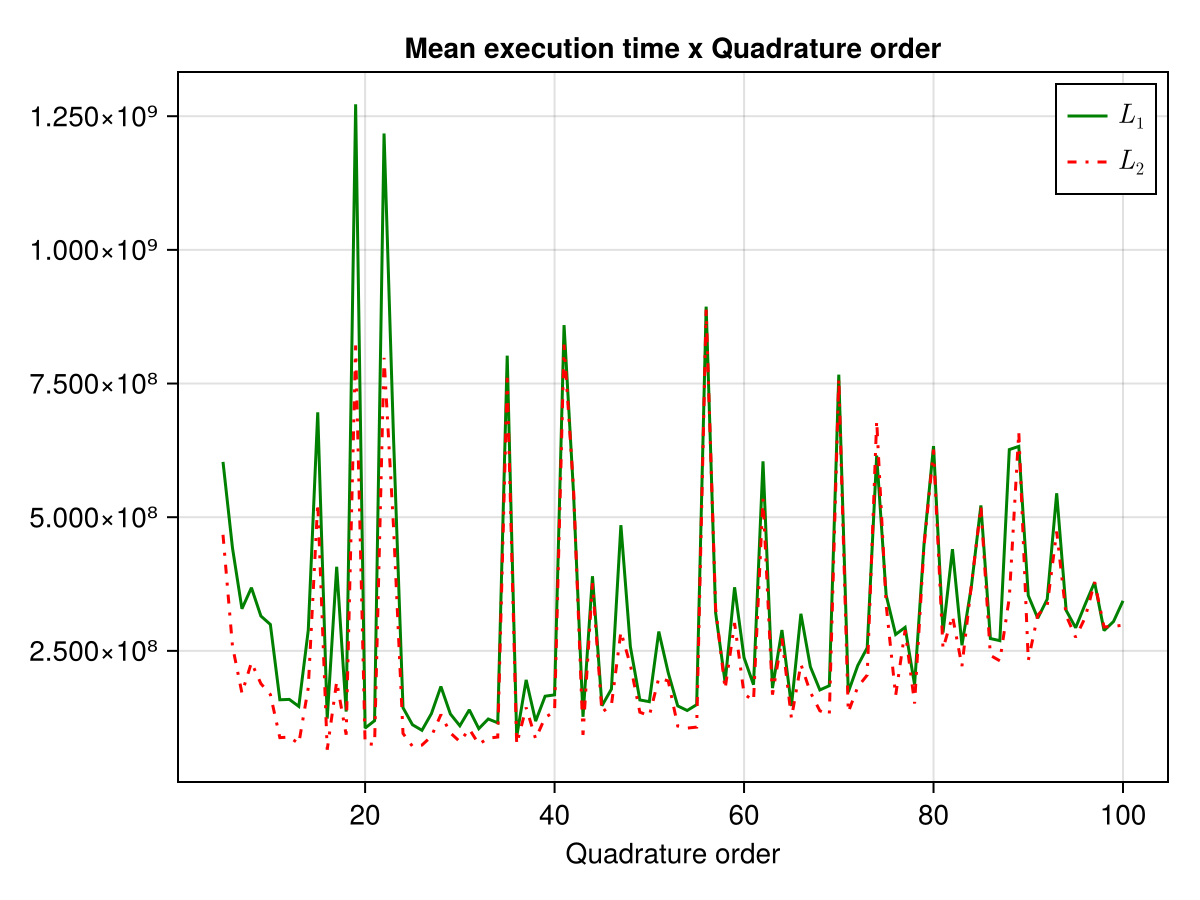

In [5]:
fig1 = Figure()
ax1 = Axis(fig1[1, 1], title="Mean execution time x Quadrature order", xlabel="Quadrature order")
lines!(ax1, qorder_vals, L₁_time, color=:green, linestyle=:solid, label=L"L_1")
lines!(ax1, qorder_vals, L₂_time, color=:red, linestyle=:dashdot, label=L"L_2")
axislegend()
save("time_qorder.svg", fig1)
fig1

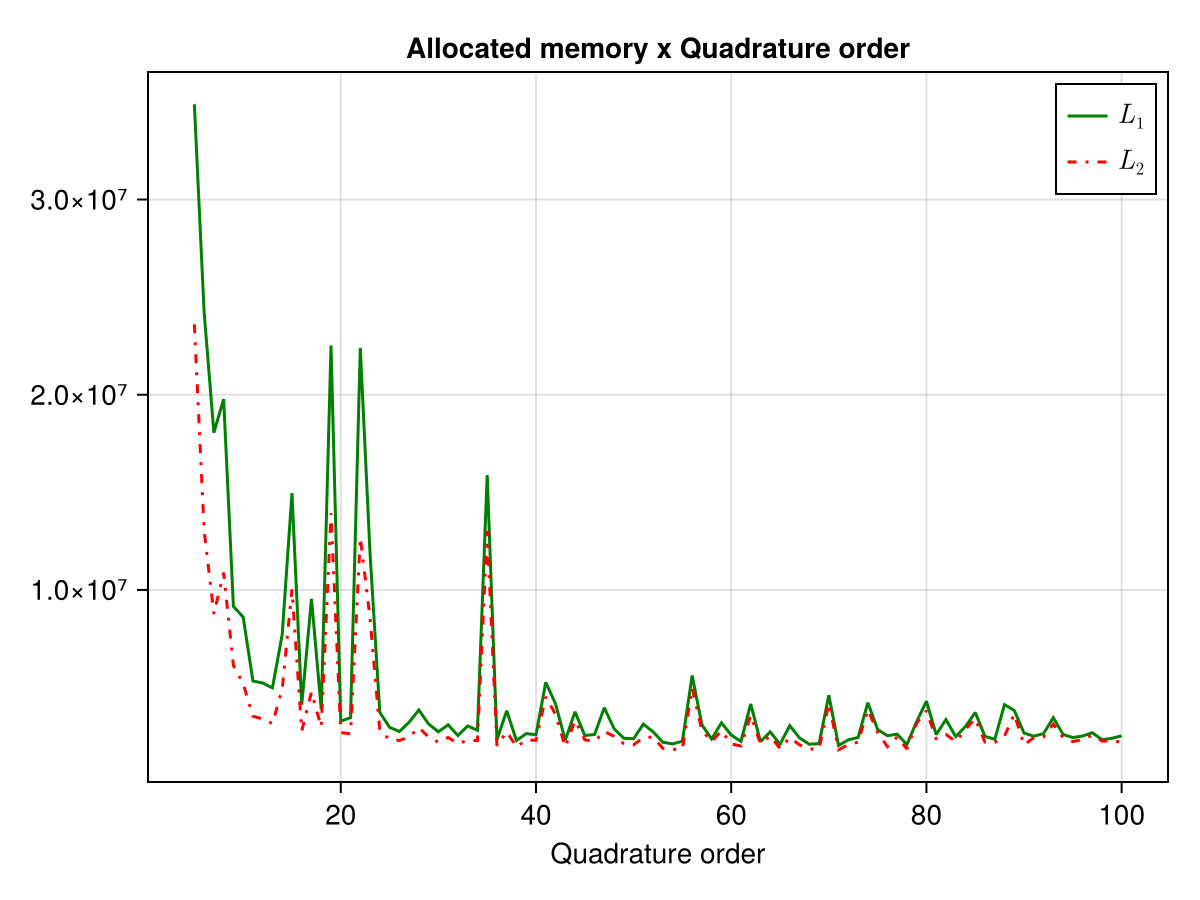

In [6]:
fig2 = Figure()
ax2 = Axis(fig2[1, 1], title="Allocated memory x Quadrature order", xlabel="Quadrature order")
lines!(ax2, qorder_vals, L₁_memory, color=:green, linestyle=:solid, label=L"L_1")
lines!(ax2, qorder_vals, L₂_memory, color=:red, linestyle=:dashdot, label=L"L_2")
axislegend()
save("memory_qorder.svg", fig2)
fig2

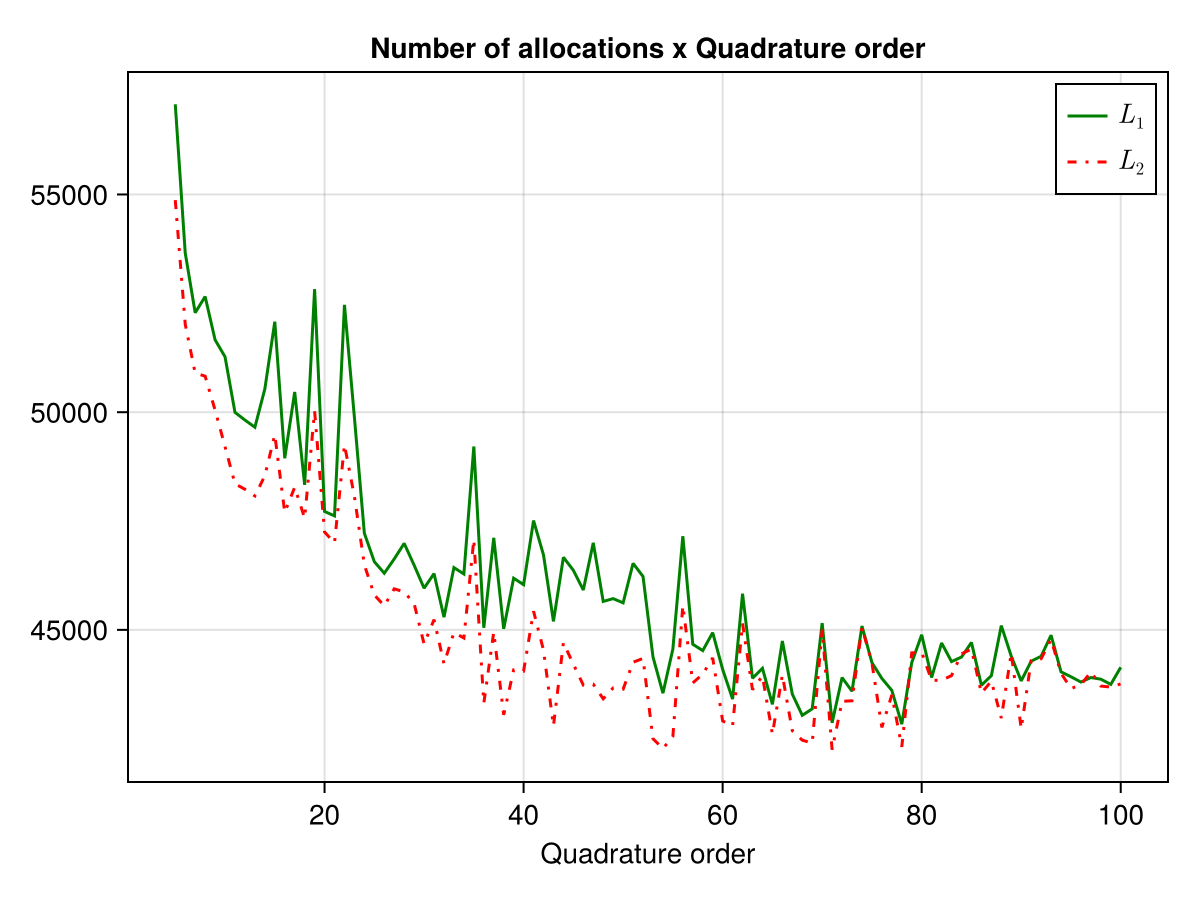

In [7]:
fig3 = Figure()
ax3 = Axis(fig3[1, 1], title="Number of allocations x Quadrature order", xlabel="Quadrature order")
lines!(ax3, qorder_vals, L₁_allocs, color=:green, linestyle=:solid, label=L"L_1")
lines!(ax3, qorder_vals, L₂_allocs, color=:red, linestyle=:dashdot, label=L"L_2")
axislegend()
save("allocations_qorder.svg", fig3)
fig3

The quadrature order is best between 24 and 34

In [8]:
L₁_time_idx = partialsortperm(L₁_time, 1:3)
L₂_time_idx = partialsortperm(L₂_time, 1:3)

print(qorder_vals[L₁_time_idx])
print(qorder_vals[L₂_time_idx])

[36, 26, 32][16, 25, 26]

In [9]:
L₁_memory_idx = partialsortperm(L₁_memory, 1:3)
L₂_memory_idx = partialsortperm(L₂_memory, 1:3)

print(qorder_vals[L₁_memory_idx])
print(qorder_vals[L₂_memory_idx])

[71, 78, 65][71, 54, 68]

In [10]:
L₁_allocs_idx = partialsortperm(L₁_allocs, 1:3)
L₂_allocs_idx = partialsortperm(L₂_allocs, 1:3)

print(qorder_vals[L₁_allocs_idx])
print(qorder_vals[L₂_allocs_idx])

[78, 71, 68][71, 54, 78]